In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/exp.csv")

In [4]:
df.head()

,Date,Category,Description,Amount,Payment_Method
0,2026-01-02,Food,Breakfast,80,UPI
1,2026-01-03,Travel,Bus,40,Cash
2,2026-01-04,Education,Books,650,UPI
3,2026-01-05,Food,Lunch,150,UPI
4,2026-01-06,Shopping,T-Shirt,799,Card


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Date            199 non-null    str  
 1   Category        199 non-null    str  
 2   Description     199 non-null    str  
 3   Amount          199 non-null    int64
 4   Payment_Method  199 non-null    str  
dtypes: int64(1), str(4)
memory usage: 13.2 KB


In [6]:
df.describe()

,Amount
count,199.000000
mean,362.597990
std,350.308377
min,40.000000
25%,110.000000
50%,250.000000
75%,450.000000
max,1599.000000


In [7]:
print(df.columns.tolist())

['Date', 'Category', 'Description', 'Amount', 'Payment_Method']


In [8]:
df["Date"] = pd.to_datetime(df["Date"])

In [9]:
df

,Date,Category,Description,Amount,Payment_Method
0,2026-01-02,Food,Breakfast,80,UPI
1,2026-01-03,Travel,Bus,40,Cash
2,2026-01-04,Education,Books,650,UPI
3,2026-01-05,Food,Lunch,150,UPI
4,2026-01-06,Shopping,T-Shirt,799,Card
...,...,...,...,...,...
194,2026-09-11,Health,Medicine,350,UPI
195,2026-09-12,Education,Stationery,200,Cash
196,2026-09-13,Shopping,Jeans,999,Card
197,2026-09-14,Food,Snacks,110,UPI


In [10]:
df.shape

(199, 5)

In [11]:
df.dtypes

Date              datetime64[us]
Category                     str
Description                  str
Amount                     int64
Payment_Method               str
dtype: object

In [12]:
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce") #coerce:  If there is something invalid in the Amount column, Pandas converts it to:

In [13]:
df.isnull().sum()

Date              0
Category          0
Description       0
Amount            0
Payment_Method    0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
int(df["Amount"].sum())

72157

In [16]:
df["Amount"].mean()

np.float64(362.59798994974875)

In [17]:
df["Amount"].max()

np.int64(1599)

In [18]:
df["Amount"].min()

np.int64(40)

In [19]:
df["Category"].unique()

<ArrowStringArray>
['Food', 'Travel', 'Education', 'Shopping', 'Entertainment', 'Bills',
 'Health']
Length: 7, dtype: str

In [20]:
df["Category"].value_counts()

Category
Food             61
Travel           36
Education        26
Shopping         26
Entertainment    24
Bills            17
Health            9
Name: count, dtype: int64

In [21]:
df.groupby("Category")["Amount"].sum()

Category
Bills             8987
Education        13505
Entertainment     6899
Food              9850
Health            3550
Shopping         26676
Travel            2690
Name: Amount, dtype: int64

In [22]:
df.columns = df.columns.str.strip()

In [23]:
print(df.columns.tolist())

['Date', 'Category', 'Description', 'Amount', 'Payment_Method']


In [24]:
total_expense = df["Amount"].sum()
print("Total Expense:", total_expense)

Total Expense: 72157


In [25]:
average_expense = df["Amount"].mean()
print("Average Expense:", average_expense)

Average Expense: 362.59798994974875


In [26]:
df.loc[df["Amount"].idxmax()]

Date              2026-03-12 00:00:00
Category                     Shopping
Description                Headphones
Amount                           1599
Payment_Method                   Card
Name: 57, dtype: object

In [27]:
category_spending = df.groupby("Category")["Amount"].sum()
print(category_spending)

Category
Bills             8987
Education        13505
Entertainment     6899
Food              9850
Health            3550
Shopping         26676
Travel            2690
Name: Amount, dtype: int64


In [28]:
category_spending = df.groupby("Category")["Amount"].sum().sort_values(ascending=False)

print(category_spending)

Category
Shopping         26676
Education        13505
Food              9850
Bills             8987
Entertainment     6899
Health            3550
Travel            2690
Name: Amount, dtype: int64


In [29]:
category_spending.idxmax()

'Shopping'

In [30]:
category_spending.max()

np.int64(26676)

In [31]:
df["Payment_Method"].value_counts()

Payment_Method
UPI     118
Cash     43
Card     38
Name: count, dtype: int64

In [32]:
payment_spending = df.groupby("Payment_Method")["Amount"].sum()

print(payment_spending)

Payment_Method
Card    30145
Cash     4200
UPI     37812
Name: Amount, dtype: int64


In [33]:
df["Month"] = df["Date"].dt.to_period("M")

In [34]:
print(df["Date"].dtype)

datetime64[us]


In [35]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [36]:
print(df["Date"].dtype)

datetime64[us]


In [37]:
print(df["Date"].isnull().sum())

0


In [38]:
df["Month"] = df["Date"].dt.to_period("M")

In [39]:
df[["Date", "Month"]].head()

,Date,Month
0,2026-01-02,2026-01
1,2026-01-03,2026-01
2,2026-01-04,2026-01
3,2026-01-05,2026-01
4,2026-01-06,2026-01


In [40]:
monthly_spending = df.groupby("Month")["Amount"].sum()

print(monthly_spending)

Month
2026-01    8573
2026-02    8106
2026-03    8005
2026-04    8305
2026-05    9045
2026-06    7946
2026-07    8255
2026-08    9405
2026-09    4517
Freq: M, Name: Amount, dtype: int64


In [41]:
monthly_transactions = df.groupby("Month").size()

print(monthly_transactions)

Month
2026-01    25
2026-02    22
2026-03    23
2026-04    23
2026-05    23
2026-06    23
2026-07    23
2026-08    23
2026-09    14
Freq: M, dtype: int64


In [42]:
summary = pd.DataFrame({
    "Total Expense": [df["Amount"].sum()],
    "Average Expense": [df["Amount"].mean()],
    "Highest Expense": [df["Amount"].max()],
    "Lowest Expense": [df["Amount"].min()],
    "Total Transactions": [len(df)]
})

summary

,Total Expense,Average Expense,Highest Expense,Lowest Expense,Total Transactions
0,72157,362.59799,1599,40,199


In [43]:
df.to_csv("../data/cleaned_expenses.csv", index=False)

In [44]:
df = pd.read_csv("../data/cleaned_expenses.csv")

In [45]:
df.head()


,Date,Category,Description,Amount,Payment_Method,Month
0,2026-01-02,Food,Breakfast,80,UPI,2026-01
1,2026-01-03,Travel,Bus,40,Cash,2026-01
2,2026-01-04,Education,Books,650,UPI,2026-01
3,2026-01-05,Food,Lunch,150,UPI,2026-01
4,2026-01-06,Shopping,T-Shirt,799,Card,2026-01


In [46]:
category_spending = df.groupby("Category")["Amount"].sum().sort_values(ascending=False)

print(category_spending)

Category
Shopping         26676
Education        13505
Food              9850
Bills             8987
Entertainment     6899
Health            3550
Travel            2690
Name: Amount, dtype: int64


(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'Shopping'),
  Text(1, 0, 'Education'),
  Text(2, 0, 'Food'),
  Text(3, 0, 'Bills'),
  Text(4, 0, 'Entertainment'),
  Text(5, 0, 'Health'),
  Text(6, 0, 'Travel')])

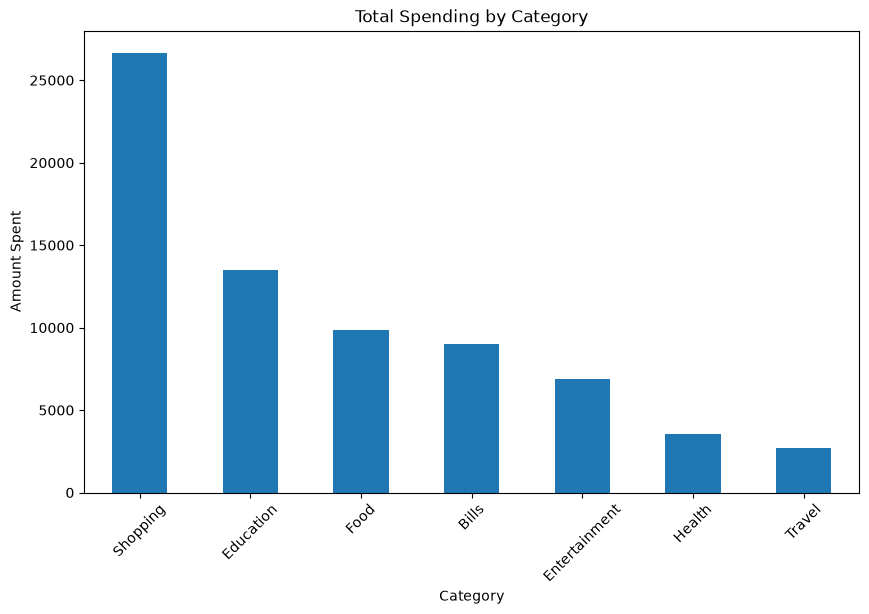

In [47]:
plt.figure(figsize=(10, 6))

category_spending.plot(kind="bar")

plt.title("Total Spending by Category")
plt.xlabel("Category")
plt.ylabel("Amount Spent")
plt.xticks(rotation=45)



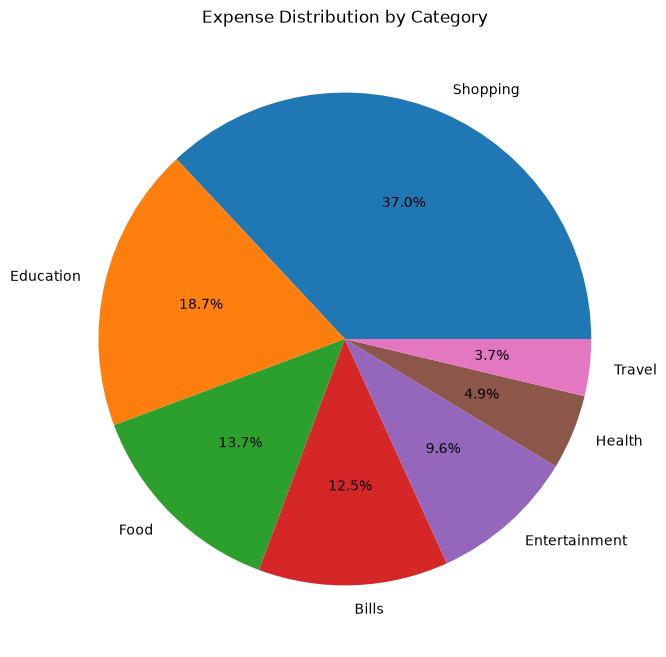

In [48]:
plt.figure(figsize=(8, 8))

category_spending.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Expense Distribution by Category")
plt.ylabel("")

plt.show()


In [49]:
monthly_spending = df.groupby("Month")["Amount"].sum()

print(monthly_spending)

Month
2026-01    8573
2026-02    8106
2026-03    8005
2026-04    8305
2026-05    9045
2026-06    7946
2026-07    8255
2026-08    9405
2026-09    4517
Name: Amount, dtype: int64


(array([-1.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9.]),
 [Text(-1.0, 0, '2026-09'),
  Text(0.0, 0, '2026-01'),
  Text(1.0, 0, '2026-02'),
  Text(2.0, 0, '2026-03'),
  Text(3.0, 0, '2026-04'),
  Text(4.0, 0, '2026-05'),
  Text(5.0, 0, '2026-06'),
  Text(6.0, 0, '2026-07'),
  Text(7.0, 0, '2026-08'),
  Text(8.0, 0, '2026-09'),
  Text(9.0, 0, '')])

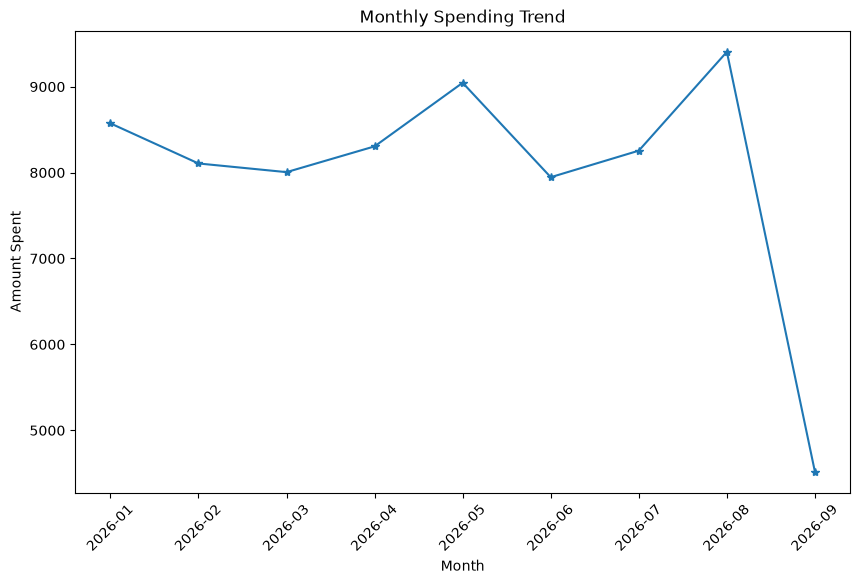

In [50]:
plt.figure(figsize=(10, 6))

monthly_spending.plot(kind="line", marker="*")

plt.title("Monthly Spending Trend")
plt.xlabel("Month")
plt.ylabel("Amount Spent")
plt.xticks(rotation=45)

In [51]:
payment_spending = df.groupby("Payment_Method")["Amount"].sum()

print(payment_spending)

Payment_Method
Card    30145
Cash     4200
UPI     37812
Name: Amount, dtype: int64


(array([0, 1, 2]), [Text(0, 0, 'Card'), Text(1, 0, 'Cash'), Text(2, 0, 'UPI')])

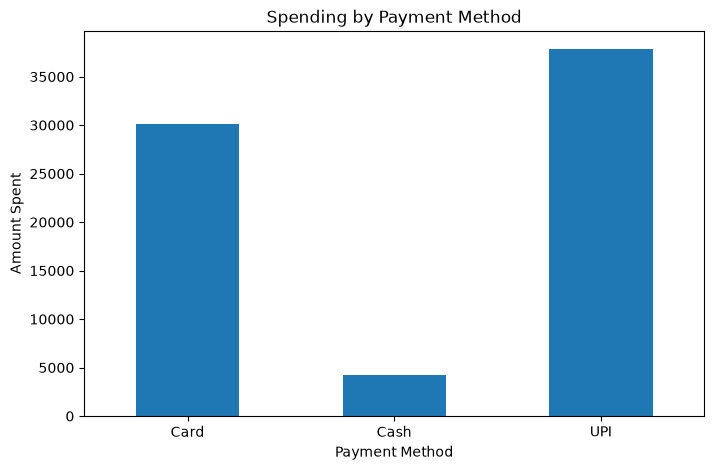

In [52]:
plt.figure(figsize=(8, 5))

payment_spending.plot(kind="bar")

plt.title("Spending by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Amount Spent")
plt.xticks(rotation=0)

In [53]:
highest_month = monthly_spending.idxmax()
highest_month_amount = monthly_spending.max()

print("Highest Spending Month:", highest_month)
print("Amount Spent:", highest_month_amount)

Highest Spending Month: 2026-08
Amount Spent: 9405


In [54]:
highest_category = category_spending.idxmax()
highest_category_amount = category_spending.max()

print("Highest Spending Category:", highest_category)
print("Amount Spent:", highest_category_amount)

Highest Spending Category: Shopping
Amount Spent: 26676


In [55]:
#we set our monthly budget
category_budget = {
    "Food": 10000,
    "Travel": 5000,
    "Education": 8000,
    "Shopping": 7000,
    "Entertainment": 4000,
    "Bills": 12000,
    "Health": 5000
}

In [56]:
category_spending = df.groupby("Category")["Amount"].sum()

In [57]:
print(category_spending)

Category
Bills             8987
Education        13505
Entertainment     6899
Food              9850
Health            3550
Shopping         26676
Travel            2690
Name: Amount, dtype: int64


In [58]:
budget_df = pd.DataFrame({
    "Category": category_budget.keys(),
    "Budget": category_budget.values()
})

budget_df

,Category,Budget
0,Food,10000
1,Travel,5000
2,Education,8000
3,Shopping,7000
4,Entertainment,4000
5,Bills,12000
6,Health,5000


In [59]:
budget_df["Actual_Spending"] = budget_df["Category"].map(category_spending)

In [60]:
budget_df

,Category,Budget,Actual_Spending
0,Food,10000,9850
1,Travel,5000,2690
2,Education,8000,13505
3,Shopping,7000,26676
4,Entertainment,4000,6899
5,Bills,12000,8987
6,Health,5000,3550


In [61]:
budget_df["Actual_Spending"] = budget_df["Actual_Spending"].fillna(0)

In [62]:
budget_df

,Category,Budget,Actual_Spending
0,Food,10000,9850
1,Travel,5000,2690
2,Education,8000,13505
3,Shopping,7000,26676
4,Entertainment,4000,6899
5,Bills,12000,8987
6,Health,5000,3550


In [63]:
#Calculate remaining budget
budget_df["Remaining"] = (
    budget_df["Budget"] - budget_df["Actual_Spending"]
)

In [64]:
budget_df

,Category,Budget,Actual_Spending,Remaining
0,Food,10000,9850,150
1,Travel,5000,2690,2310
2,Education,8000,13505,-5505
3,Shopping,7000,26676,-19676
4,Entertainment,4000,6899,-2899
5,Bills,12000,8987,3013
6,Health,5000,3550,1450


In [65]:
budget_df["Status"] = budget_df.apply(
    lambda row: "Over Budget"
    if row["Actual_Spending"] > row["Budget"]
    else "Within Budget",
    axis=1
)

In [66]:
budget_df

,Category,Budget,Actual_Spending,Remaining,Status
0,Food,10000,9850,150,Within Budget
1,Travel,5000,2690,2310,Within Budget
2,Education,8000,13505,-5505,Over Budget
3,Shopping,7000,26676,-19676,Over Budget
4,Entertainment,4000,6899,-2899,Over Budget
5,Bills,12000,8987,3013,Within Budget
6,Health,5000,3550,1450,Within Budget


In [67]:
budget_df["Used_Percentage"] = (
    budget_df["Actual_Spending"] / budget_df["Budget"]
) * 100

In [68]:
budget_df

,Category,Budget,Actual_Spending,Remaining,Status,Used_Percentage
0,Food,10000,9850,150,Within Budget,98.500000
1,Travel,5000,2690,2310,Within Budget,53.800000
2,Education,8000,13505,-5505,Over Budget,168.812500
3,Shopping,7000,26676,-19676,Over Budget,381.085714
4,Entertainment,4000,6899,-2899,Over Budget,172.475000
5,Bills,12000,8987,3013,Within Budget,74.891667
6,Health,5000,3550,1450,Within Budget,71.000000


In [69]:
over_budget = budget_df[
    budget_df["Actual_Spending"] > budget_df["Budget"]
]

over_budget

,Category,Budget,Actual_Spending,Remaining,Status,Used_Percentage
2,Education,8000,13505,-5505,Over Budget,168.812500
3,Shopping,7000,26676,-19676,Over Budget,381.085714
4,Entertainment,4000,6899,-2899,Over Budget,172.475000


In [70]:
for _, row in over_budget.iterrows():
    excess = row["Actual_Spending"] - row["Budget"]
    
    print(
        f"ALERT: {row['Category']} budget exceeded by ₹{excess:.2f}"
    )

ALERT: Education budget exceeded by ₹5505.00
ALERT: Shopping budget exceeded by ₹19676.00
ALERT: Entertainment budget exceeded by ₹2899.00


In [71]:
budget_report = budget_df[
    [
        "Category",
        "Budget",
        "Actual_Spending",
        "Remaining",
        "Used_Percentage",
        "Status"
    ]
]

budget_report

,Category,Budget,Actual_Spending,Remaining,Used_Percentage,Status
0,Food,10000,9850,150,98.500000,Within Budget
1,Travel,5000,2690,2310,53.800000,Within Budget
2,Education,8000,13505,-5505,168.812500,Over Budget
3,Shopping,7000,26676,-19676,381.085714,Over Budget
4,Entertainment,4000,6899,-2899,172.475000,Over Budget
5,Bills,12000,8987,3013,74.891667,Within Budget
6,Health,5000,3550,1450,71.000000,Within Budget


In [72]:
total_budget = budget_df["Budget"].sum()
total_spending = budget_df["Actual_Spending"].sum()
remaining_budget = total_budget - total_spending

In [73]:
print("Total Budget:", total_budget)
print("Total Spending:", total_spending)
print("Remaining Budget:", remaining_budget)

Total Budget: 51000
Total Spending: 72157
Remaining Budget: -21157


In [74]:
if total_spending > total_budget:
    print("Overall Status: Budget Exceeded")
else:
    print("Overall Status: Within Budget")

Overall Status: Budget Exceeded


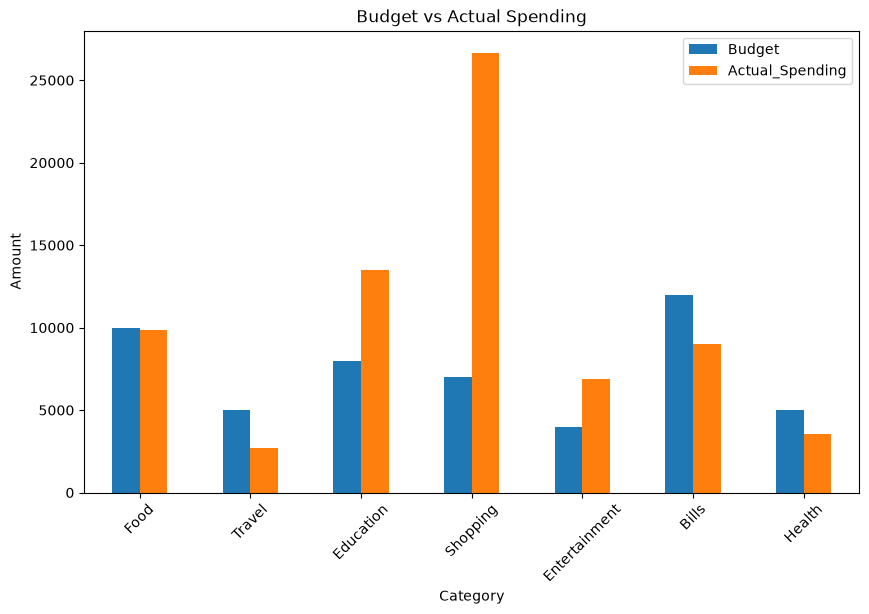

In [75]:
budget_compare = budget_df.set_index("Category")[
    ["Budget", "Actual_Spending"]
]

budget_compare.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Budget vs Actual Spending")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=45)

plt.show()

In [76]:
budget_report.to_csv(
    "../data/budget_report.csv",
    index=False
)

In [77]:
## 8. Advanced Expense Analysis
df["Date"]

0      2026-01-02
1      2026-01-03
2      2026-01-04
3      2026-01-05
4      2026-01-06
          ...    
194    2026-09-11
195    2026-09-12
196    2026-09-13
197    2026-09-14
198    2026-09-15
Name: Date, Length: 199, dtype: str

In [90]:
df["Day"] = df["Date"].dt.day_name()

AttributeError: Can only use .dt accessor with datetimelike values

In [91]:
print(df["Date"].dtype)

str


In [92]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [93]:
print(df["Date"].dtype)

datetime64[us]


In [94]:
df["Day"] = df["Date"].dt.day_name()

In [95]:
df[["Date", "Day"]].head()

,Date,Day
0,2026-01-02,Friday
1,2026-01-03,Saturday
2,2026-01-04,Sunday
3,2026-01-05,Monday
4,2026-01-06,Tuesday


In [96]:
day_spending = df.groupby("Day")["Amount"].sum()

print(day_spending)

Day
Friday        9114
Monday        9755
Saturday     10524
Sunday       10862
Thursday     12533
Tuesday      10982
Wednesday     8387
Name: Amount, dtype: int64


In [97]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

In [98]:
day_spending = day_spending.reindex(day_order)

print(day_spending)

Day
Monday        9755
Tuesday      10982
Wednesday     8387
Thursday     12533
Friday        9114
Saturday     10524
Sunday       10862
Name: Amount, dtype: int64


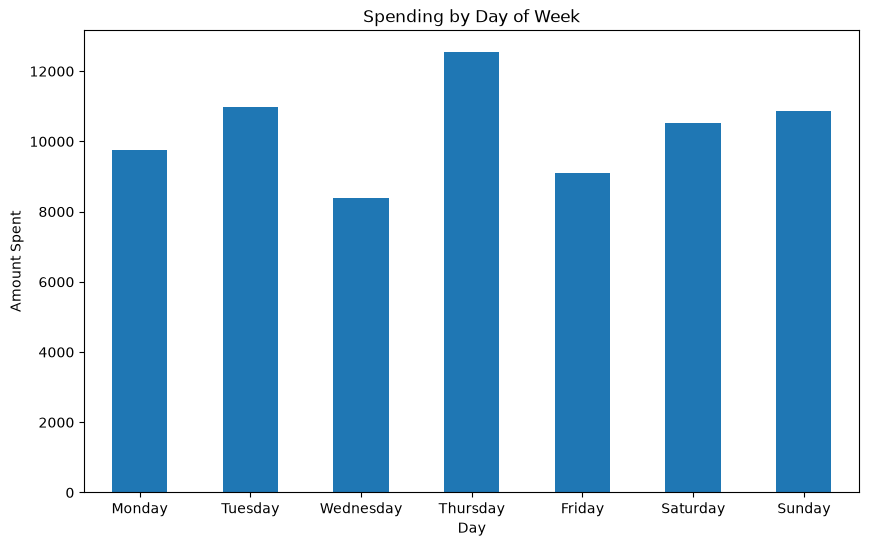

In [99]:
plt.figure(figsize=(10, 6))

day_spending.plot(kind="bar")

plt.title("Spending by Day of Week")
plt.xlabel("Day")
plt.ylabel("Amount Spent")
plt.xticks(rotation=0)

plt.show()

In [100]:
highest_day = day_spending.idxmax()
highest_day_amount = day_spending.max()

print("Highest Spending Day:", highest_day)
print("Amount Spent:", highest_day_amount)

Highest Spending Day: Thursday
Amount Spent: 12533


In [101]:
df["Day_Type"] = df["Date"].dt.dayofweek.apply(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

In [102]:
day_type_spending = df.groupby("Day_Type")["Amount"].sum()

print(day_type_spending)

Day_Type
Weekday    50771
Weekend    21386
Name: Amount, dtype: int64


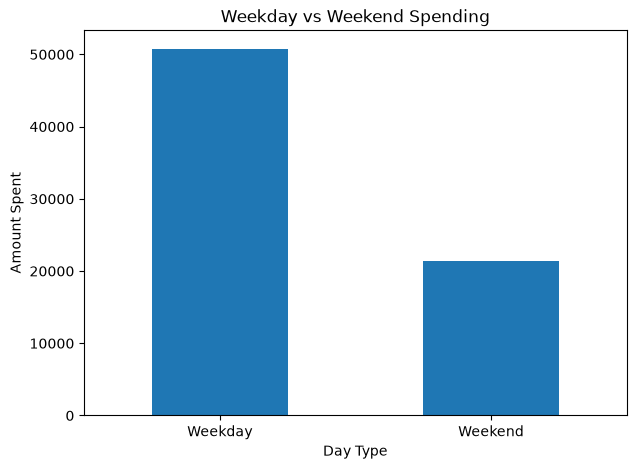

In [103]:
plt.figure(figsize=(7, 5))

day_type_spending.plot(kind="bar")

plt.title("Weekday vs Weekend Spending")
plt.xlabel("Day Type")
plt.ylabel("Amount Spent")
plt.xticks(rotation=0)

plt.show()

In [104]:
top_expenses = df.sort_values(
    by="Amount",
    ascending=False
).head(10)

In [105]:
top_expenses

,Date,Category,Description,Amount,Payment_Method,Month,Day,Day_Type
57,2026-03-12,Shopping,Headphones,1599,Card,2026-03,Thursday,Weekday
10,2026-01-14,Shopping,Shoes,1499,Card,2026-01,Wednesday,Weekday
111,2026-05-24,Shopping,Watch,1499,Card,2026-05,Sunday,Weekend
157,2026-07-24,Shopping,Headphones,1499,Card,2026-07,Friday,Weekday
173,2026-08-14,Shopping,Shoes,1399,Card,2026-08,Friday,Weekday
127,2026-06-14,Shopping,Shoes,1399,Card,2026-06,Sunday,Weekend
81,2026-04-14,Shopping,Shoes,1299,Card,2026-04,Tuesday,Weekday
180,2026-08-24,Shopping,Watch,1299,Card,2026-08,Monday,Weekday
44,2026-02-26,Shopping,Watch,1200,Card,2026-02,Thursday,Weekday
97,2026-05-05,Shopping,Jeans,1099,Card,2026-05,Tuesday,Weekday


In [106]:
average_by_category = df.groupby("Category")["Amount"].mean()

print(average_by_category)

Category
Bills             528.647059
Education         519.423077
Entertainment     287.458333
Food              161.475410
Health            394.444444
Shopping         1026.000000
Travel             74.722222
Name: Amount, dtype: float64


In [107]:
average_by_category = average_by_category.sort_values(
    ascending=False
)

print(average_by_category)

Category
Shopping         1026.000000
Bills             528.647059
Education         519.423077
Health            394.444444
Entertainment     287.458333
Food              161.475410
Travel             74.722222
Name: Amount, dtype: float64


In [108]:
total_expense = df["Amount"].sum()

In [109]:
category_percentage = (
    category_spending / total_expense
) * 100

In [110]:
print(category_percentage)

Category
Bills            12.454786
Education        18.716133
Entertainment     9.561096
Food             13.650789
Health            4.919828
Shopping         36.969386
Travel            3.727982
Name: Amount, dtype: float64


In [111]:
category_report = pd.DataFrame({
    "Total_Spending": category_spending,
    "Percentage": category_percentage,
    "Average_Transaction": average_by_category
})

In [112]:
category_report = category_report.sort_values("Total_Spending", ascending=False)

In [113]:
category_report

,Total_Spending,Percentage,Average_Transaction
Category,,,
Shopping,26676,36.969386,1026.000000
Education,13505,18.716133,519.423077
Food,9850,13.650789,161.475410
Bills,8987,12.454786,528.647059
Entertainment,6899,9.561096,287.458333
Health,3550,4.919828,394.444444
Travel,2690,3.727982,74.722222


In [114]:
large_expenses = df[df["Amount"] > 1300]

In [115]:
large_expenses

,Date,Category,Description,Amount,Payment_Method,Month,Day,Day_Type
10,2026-01-14,Shopping,Shoes,1499,Card,2026-01,Wednesday,Weekday
57,2026-03-12,Shopping,Headphones,1599,Card,2026-03,Thursday,Weekday
111,2026-05-24,Shopping,Watch,1499,Card,2026-05,Sunday,Weekend
127,2026-06-14,Shopping,Shoes,1399,Card,2026-06,Sunday,Weekend
157,2026-07-24,Shopping,Headphones,1499,Card,2026-07,Friday,Weekday
173,2026-08-14,Shopping,Shoes,1399,Card,2026-08,Friday,Weekday


In [116]:
print(
    "Number of large transactions:",
    len(large_expenses)
)

Number of large transactions: 6


In [117]:
print(df["Date"].dtype)

datetime64[us]


In [118]:
import sqlite3

In [119]:
conn = sqlite3.connect("../data/expenses.db")

In [120]:
cursor = conn.cursor()

In [121]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS expenses (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    date TEXT,
    category TEXT,
    description TEXT,
    amount REAL,
    payment_method TEXT
)
""")

In [122]:
conn.commit()

In [123]:
cursor.execute("""
INSERT INTO expenses
(date, category, description, amount, payment_method)
VALUES (?, ?, ?, ?, ?)
""", (
    "2026-01-10",
    "Food",
    "Lunch",
    250,
    "UPI"
))

In [124]:
conn.commit()

In [125]:
cursor.execute("SELECT * FROM expenses")

rows = cursor.fetchall()

rows

[(1, '2026-01-10', 'Food', 'Lunch', 250.0, 'UPI'),
 (2, '2026-01-02', 'Food', 'Breakfast', 80.0, 'UPI'),
 (3, '2026-01-03', 'Travel', 'Bus', 40.0, 'Cash'),
 (4, '2026-01-04', 'Education', 'Books', 650.0, 'UPI'),
 (5, '2026-01-05', 'Food', 'Lunch', 150.0, 'UPI'),
 (6, '2026-01-06', 'Shopping', 'T-Shirt', 799.0, 'Card'),
 (7, '2026-01-07', 'Entertainment', 'Movie', 250.0, 'UPI'),
 (8, '2026-01-08', 'Travel', 'Auto', 120.0, 'Cash'),
 (9, '2026-01-10', 'Food', 'Dinner', 220.0, 'UPI'),
 (10, '2026-01-11', 'Bills', 'Mobile Recharge', 299.0, 'UPI'),
 (11, '2026-01-12', 'Education', 'Notebook', 120.0, 'Cash'),
 (12, '2026-01-14', 'Shopping', 'Shoes', 1499.0, 'Card'),
 (13, '2026-01-15', 'Food', 'Snacks', 90.0, 'Cash'),
 (14, '2026-01-16', 'Travel', 'Metro', 60.0, 'UPI'),
 (15, '2026-01-18', 'Entertainment', 'OTT Subscription', 199.0, 'Card'),
 (16, '2026-01-20', 'Food', 'Lunch', 180.0, 'UPI'),
 (17, '2026-01-21', 'Health', 'Medicine', 350.0, 'UPI'),
 (18, '2026-01-22', 'Travel', 'Bus', 50.0, '

In [126]:
df.head()

,Date,Category,Description,Amount,Payment_Method,Month,Day,Day_Type
0,2026-01-02,Food,Breakfast,80,UPI,2026-01,Friday,Weekday
1,2026-01-03,Travel,Bus,40,Cash,2026-01,Saturday,Weekend
2,2026-01-04,Education,Books,650,UPI,2026-01,Sunday,Weekend
3,2026-01-05,Food,Lunch,150,UPI,2026-01,Monday,Weekday
4,2026-01-06,Shopping,T-Shirt,799,Card,2026-01,Tuesday,Weekday


In [127]:
for _, row in df.iterrows():
    cursor.execute("""
    INSERT INTO expenses
    (date, category, description, amount, payment_method)
    VALUES (?, ?, ?, ?, ?)
    """, (
        row["Date"].strftime("%Y-%m-%d"),
        row["Category"],
        row["Description"],
        float(row["Amount"]),
        row["Payment_Method"]
    ))

conn.commit()

In [128]:
cursor.execute("SELECT * FROM expenses")

rows = cursor.fetchall()

rows

[(1, '2026-01-10', 'Food', 'Lunch', 250.0, 'UPI'),
 (2, '2026-01-02', 'Food', 'Breakfast', 80.0, 'UPI'),
 (3, '2026-01-03', 'Travel', 'Bus', 40.0, 'Cash'),
 (4, '2026-01-04', 'Education', 'Books', 650.0, 'UPI'),
 (5, '2026-01-05', 'Food', 'Lunch', 150.0, 'UPI'),
 (6, '2026-01-06', 'Shopping', 'T-Shirt', 799.0, 'Card'),
 (7, '2026-01-07', 'Entertainment', 'Movie', 250.0, 'UPI'),
 (8, '2026-01-08', 'Travel', 'Auto', 120.0, 'Cash'),
 (9, '2026-01-10', 'Food', 'Dinner', 220.0, 'UPI'),
 (10, '2026-01-11', 'Bills', 'Mobile Recharge', 299.0, 'UPI'),
 (11, '2026-01-12', 'Education', 'Notebook', 120.0, 'Cash'),
 (12, '2026-01-14', 'Shopping', 'Shoes', 1499.0, 'Card'),
 (13, '2026-01-15', 'Food', 'Snacks', 90.0, 'Cash'),
 (14, '2026-01-16', 'Travel', 'Metro', 60.0, 'UPI'),
 (15, '2026-01-18', 'Entertainment', 'OTT Subscription', 199.0, 'Card'),
 (16, '2026-01-20', 'Food', 'Lunch', 180.0, 'UPI'),
 (17, '2026-01-21', 'Health', 'Medicine', 350.0, 'UPI'),
 (18, '2026-01-22', 'Travel', 'Bus', 50.0, '

In [129]:
db_df = pd.read_sql_query(
    "SELECT * FROM expenses",
    conn
)

db_df.head()

,id,date,category,description,amount,payment_method
0,1,2026-01-10,Food,Lunch,250.0,UPI
1,2,2026-01-02,Food,Breakfast,80.0,UPI
2,3,2026-01-03,Travel,Bus,40.0,Cash
3,4,2026-01-04,Education,Books,650.0,UPI
4,5,2026-01-05,Food,Lunch,150.0,UPI


In [130]:
cursor.execute("SELECT COUNT(*) FROM expenses")

count = cursor.fetchone()[0]

print("Total expenses:", count)

Total expenses: 400


In [131]:
cursor.execute("""
SELECT SUM(amount)
FROM expenses
""")

total = cursor.fetchone()[0]

print("Total Spending:", total)

Total Spending: 144814.0


In [132]:
category_sql = pd.read_sql_query("""
SELECT category, SUM(amount) AS total_spending
FROM expenses
GROUP BY category
ORDER BY total_spending DESC
""", conn)

category_sql

,category,total_spending
0,Shopping,53352.0
1,Education,27010.0
2,Food,20200.0
3,Bills,17974.0
4,Entertainment,13798.0
5,Health,7100.0
6,Travel,5380.0


In [133]:
payment_sql = pd.read_sql_query("""
SELECT payment_method, SUM(amount) AS total_spending
FROM expenses
GROUP BY payment_method
ORDER BY total_spending DESC
""", conn)

payment_sql

,payment_method,total_spending
0,UPI,76124.0
1,Card,60290.0
2,Cash,8400.0


In [134]:
biggest_expense = pd.read_sql_query("""
SELECT *
FROM expenses
ORDER BY amount DESC
LIMIT 1
""", conn)

biggest_expense

,id,date,category,description,amount,payment_method
0,59,2026-03-12,Shopping,Headphones,1599.0,Card


In [135]:
conn.close()

In [136]:
# Prepare monthly expense data for Machine Learning

monthly_ml = df.copy()

# Convert each date into its month
monthly_ml["Month"] = monthly_ml["Date"].dt.to_period("M")

# Calculate total spending for each month
monthly_ml = (
    monthly_ml
    .groupby("Month")["Amount"]
    .sum()
    .reset_index()
)


# Display the ML dataset
monthly_ml

,Month,Amount
0,2026-01,8573
1,2026-02,8106
2,2026-03,8005
3,2026-04,8305
4,2026-05,9045
5,2026-06,7946
6,2026-07,8255
7,2026-08,9405
8,2026-09,4517


In [137]:
# Create a numerical time feature for Machine Learning

monthly_ml["Month_Number"] = range(1, len(monthly_ml) + 1)

# Input feature (X)
X = monthly_ml[["Month_Number"]]

# Target/output (y)
y = monthly_ml["Amount"]

print("X (Input):")
print(X)

print("\ny (Target):")
print(y)

X (Input):
   Month_Number
0             1
1             2
2             3
3             4
4             5
5             6
6             7
7             8
8             9

y (Target):
0    8573
1    8106
2    8005
3    8305
4    9045
5    7946
6    8255
7    9405
8    4517
Name: Amount, dtype: int64


In [138]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:")
print(X_train)

print("\nTesting data:")
print(X_test)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

Training data:
   Month_Number
5             6
0             1
8             9
2             3
4             5
3             4
6             7

Testing data:
   Month_Number
7             8
1             2

Training samples: 7
Testing samples: 2


In [139]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
model = LinearRegression()

# Train the model using training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [141]:
# Predict expenses for the test data

y_pred = model.predict(X_test)

print("Actual expenses:")
print(y_test.values)

print("\nPredicted expenses:")
print(y_pred)

Actual expenses:
[9405 8106]

Predicted expenses:
[6657.78571429 8955.35714286]


In [142]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Model Evaluation
-----------------
MAE : 1798.2857142857138
RMSE: 2033.2970623786264
R²  : -8.8003899342896


In [143]:
# Predict the expense for the next month

next_month = len(monthly_ml) + 1

next_month_prediction = model.predict(
    [[next_month]]
)

print(
    f"Predicted expense for Month {next_month}: "
    f"₹{next_month_prediction[0]:,.2f}"
)

Predicted expense for Month 10: ₹5,891.93


C:\Users\rochi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


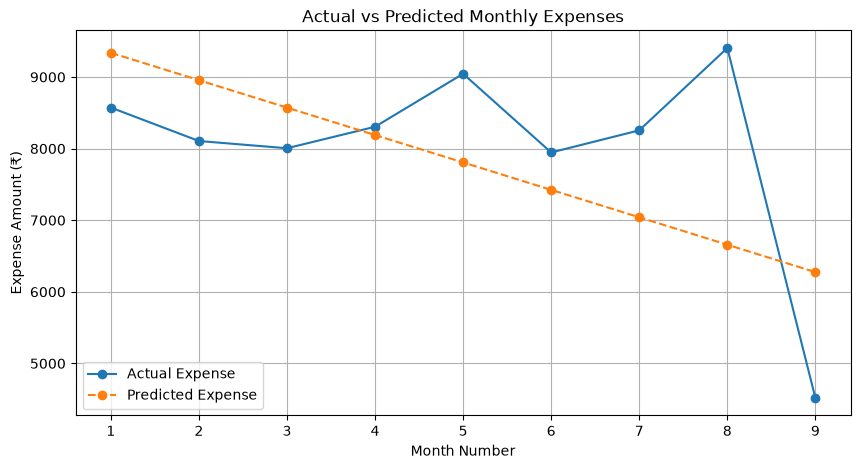

In [144]:
import matplotlib.pyplot as plt

# Predict expenses for all available months
all_predictions = model.predict(X)

plt.figure(figsize=(10, 5))

# Actual expenses
plt.plot(
    monthly_ml["Month_Number"],
    monthly_ml["Amount"],
    marker="o",
    label="Actual Expense"
)

# Predicted expenses
plt.plot(
    monthly_ml["Month_Number"],
    all_predictions,
    marker="o",
    linestyle="--",
    label="Predicted Expense"
)

plt.xlabel("Month Number")
plt.ylabel("Expense Amount (₹)")
plt.title("Actual vs Predicted Monthly Expenses")

plt.legend()
plt.grid(True)

plt.show()